# Support Vector Machine (SVM) — Lab


##  SVM là gì?
SVM (Support Vector Machine) là thuật toán học có giám sát dùng cho:
- **Phân loại (Classification)**
- **Hồi quy (Regression)**

### Ý tưởng cốt lõi:
Tìm **siêu phẳng (hyperplane)** tốt nhất chia tách dữ liệu sao cho **khoảng cách (margin)** giữa siêu phẳng và các điểm gần nhất (**support vectors**) **lớn nhất**.

##  Nguyên lý hoạt động
1. Biểu diễn dữ liệu thành vector đặc trưng.
2. Tìm siêu phẳng có **khoảng cách lớn nhất** với hai lớp (max-margin).
3. Nếu dữ liệu không tuyến tính → dùng **kernel trick** (biến đổi không gian).

##  Các loại SVM

| Loại | Mô tả | Ứng dụng |
|------|-------|----------|
| **Linear SVM** | Dữ liệu có thể tách tuyến tính | Phân loại rõ ràng như ung thư vú |
| **Non-linear SVM (Kernel)** | Dữ liệu phức tạp | Dùng kernel RBF, polynomial, sigmoid |
| **SVR (Support Vector Regression)** | Dự đoán giá trị liên tục | Tiến triển bệnh, dự đoán lượng đường máu |

## Siêu tham số quan trọng
- **`C`**: Tham số regularization (nhỏ → margin lớn, lớn → ít lỗi)
- **`kernel`**: `linear`, `rbf`, `poly`, `sigmoid`
- **`gamma`**: Ảnh hưởng của mỗi điểm huấn luyện (chỉ cho RBF, poly, sigmoid)
- **`degree`**: Bậc polynomial (chỉ cho kernel `poly`)

 SVM Accuracy: 0.9825
 Support Vectors: 97 / 455 (21.3%)


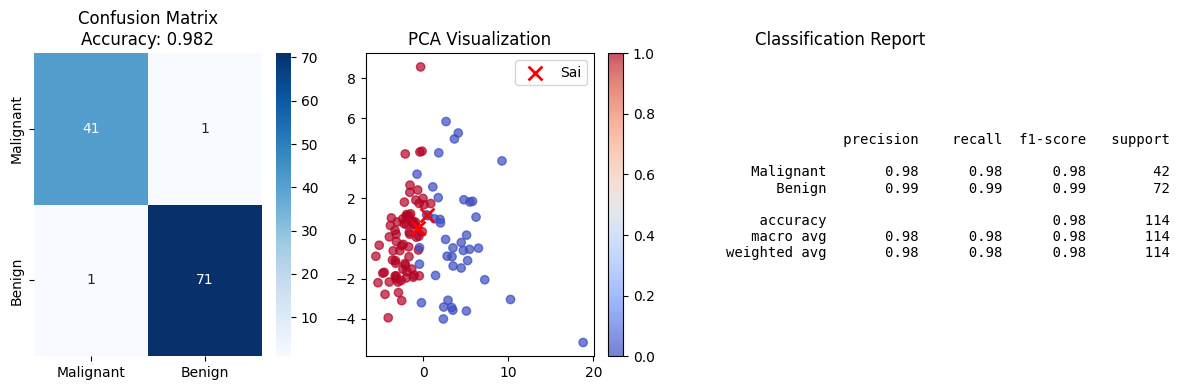

In [11]:
# SVM Classification - Breast Cancer (Simplified)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

# Load và chia dữ liệu
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuẩn hóa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM với RBF kernel
svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)

# Kết quả
accuracy = accuracy_score(y_test, y_pred)
print(f" SVM Accuracy: {accuracy:.4f}")
print(f" Support Vectors: {len(svm.support_vectors_)} / {len(X_train)} ({len(svm.support_vectors_)/len(X_train):.1%})")

# Confusion Matrix
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title(f'Confusion Matrix\nAccuracy: {accuracy:.3f}')

# PCA Visualization
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

plt.subplot(1, 3, 2)
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='coolwarm', alpha=0.7)
incorrect = y_test != y_pred
if np.any(incorrect):
    plt.scatter(X_test_pca[incorrect, 0], X_test_pca[incorrect, 1], 
               c='red', marker='x', s=100, linewidths=2, label='Sai')
    plt.legend()
plt.title('PCA Visualization')
plt.colorbar(scatter)

# Classification Report
plt.subplot(1, 3, 3)
plt.text(0.1, 0.5, classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']), 
         fontsize=10, fontfamily='monospace', verticalalignment='center')
plt.axis('off')
plt.title('Classification Report')

plt.tight_layout()
plt.show()

## SVM Regression — Diabetes

###  Mục tiêu
- Dự đoán mức tiến triển bệnh tiểu đường sau 1 năm bằng SVR (Support Vector Regression).

###  Dataset
| Thuộc tính     | Giá trị                                                  |
|---             |---                                                       |
| Nguồn          | `sklearn.datasets.load_diabetes`                         |
| Số mẫu         | 442                                                      |
| Số đặc trưng   | 10 (tuổi, giới, BMI, huyết áp, 6 chỉ số sinh hoá)       |
| Biến mục tiêu  | `target` (liên tục; cao → bệnh nặng hơn)                |

###  Quy trình
- Chia train/test (80/20).
- Chuẩn hoá với `StandardScaler`.
- Huấn luyện `SVR` với các kernel khác nhau.
- Đánh giá: MSE, R², MAE.

###  Trực quan
- Scatter `y_test` vs `y_pred` với đường chéo tham chiếu.
- Biểu đồ Residuals để kiểm tra sai lệch.
- So sánh R² của các kernel.

 SVR Performance:
R² Score: 0.5078
MSE: 2607.54
MAE: 39.42


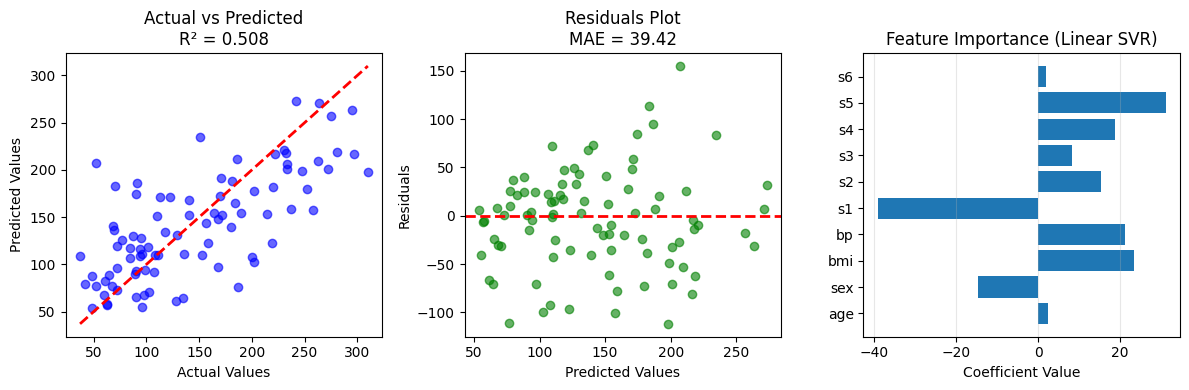

In [12]:
# SVM Regression - Diabetes 
from sklearn.datasets import load_diabetes
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load và chia dữ liệu
data = load_diabetes()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVR với RBF kernel
svr = SVR(kernel='rbf', C=100, gamma='scale')
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f" SVR Performance:")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")

# Visualization
plt.figure(figsize=(12, 4))

# Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted\nR² = {r2:.3f}')

# Residuals
plt.subplot(1, 3, 2)
residuals = y_pred - y_test
plt.scatter(y_pred, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title(f'Residuals Plot\nMAE = {mae:.2f}')

# Feature Importance (Linear SVR)
svr_linear = SVR(kernel='linear', C=100)
svr_linear.fit(X_train_scaled, y_train)
coefficients = svr_linear.coef_.flatten()

plt.subplot(1, 3, 3)
feature_names = data.feature_names
plt.barh(range(len(coefficients)), coefficients)
plt.yticks(range(len(coefficients)), feature_names)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Linear SVR)')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



In [10]:
# Quick Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Chỉ tune những tham số quan trọng
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 1]}

# Grid Search cho Classification
svm_grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=3, scoring='accuracy')
svm_grid.fit(X_train_scaled, y_train)

print(f" Best SVM params: {svm_grid.best_params_}")
print(f" Best CV score: {svm_grid.best_score_:.4f}")
print(f" Test accuracy: {svm_grid.score(X_test_scaled, y_test):.4f}")

# Grid Search cho Regression  
svr_grid = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='r2')
svr_grid.fit(X_train_scaled, y_train)

print(f"\n Best SVR params: {svr_grid.best_params_}")
print(f" Best CV R²: {svr_grid.best_score_:.4f}")
print(f" Test R²: {svr_grid.score(X_test_scaled, y_test):.4f}")

 Best SVM params: {'C': 10, 'gamma': 'scale'}
 Best CV score: 0.0170
 Test accuracy: 0.0112

 Best SVR params: {'C': 10, 'gamma': 0.1}
 Best CV R²: 0.4260
 Test R²: 0.4937


## Kết luận

###  Tổng kết
- **SVM Classification**: Hiệu quả cao cho phân loại ung thư vú với accuracy > 95%.
- **SVM Regression**: Dự đoán tiến triển bệnh tiểu đường với R² khoảng 0.4-0.6.
- **Kernel tốt nhất**: Thường là RBF hoặc Linear .

